In [1]:
print("all ok")

all ok


In [2]:
import sys, os

# Get project root — one level up from 'research_and_analyst'
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Project root added to path: d:\ARTIFICIAL INTELLIGENCE\Multi-Agent System for Research Analysis and Generation Automation\automated-research-synthesis


In [3]:
from research_and_analyst.utils.model_loader import ModelLoader

In [4]:
model_loader = ModelLoader()

{"timestamp": "2026-08-19T09:02:28.316676Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-08-19T09:02:28.317522Z", "level": "info", "event": "ANTHROPIC_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T09:02:28.317913Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T09:02:28.318237Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T09:02:28.318579Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "D:\\ARTIFICIAL INTELLIGENCE\\Multi-Agent System for Research Analysis and Generation Automation\\automated-research-synthesis\\research_and_analyst\\config\\configuration.yaml", "keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-08-19T09:02:28.320904Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["astra_db", "embeddin

In [5]:
llm=model_loader.load_llm()

{"provider": "anthropic", "model": "claude-sonnet-4-5-20250929", "timestamp": "2026-08-19T09:02:28.328776Z", "level": "info", "event": "Loading LLM"}
{"provider": "anthropic", "model": "claude-sonnet-4-5-20250929", "timestamp": "2026-08-19T09:02:28.329676Z", "level": "info", "event": "LLM loaded successfully"}


In [6]:
llm.invoke("hi").content

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


'Hello! How can I help you today?'

In [7]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [9]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

In [10]:
Analyst(
    name="Nikhil Srivastava",
    role="Agentic AI eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )

Analyst(name='Nikhil Srivastava', role='Agentic AI eng', affiliation='AI Research LAB', description='I am genai developer as well as mentor')

In [11]:
analyst = Analyst(
    name="Nikhil Srivastava",
    role="Agentic AI eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )

In [12]:
analyst.name

'Nikhil Srivastava'

In [13]:
analyst.role

'Agentic AI eng'

In [14]:
analyst.affiliation

'AI Research LAB'

In [15]:
print(analyst.persona)

Name: Nikhil Srivastava
Role: Agentic AI eng
Affiliation: AI Research LAB
Description: I am genai developer as well as mentor



In [16]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [17]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [18]:
GenerateAnalystsState(
    topic = "finance",
    max_analysts= 5,
    human_analyst_feedback= "give the real info",  
)

{'topic': 'finance',
 'max_analysts': 5,
 'human_analyst_feedback': 'give the real info'}

In [19]:
Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
    ),

(Analyst(name='Dr. Neha Patel', role='Medical Data Scientist', affiliation='Stanford Medicine', description='Focuses on predictive models for patient outcomes.'),)

In [20]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [21]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [22]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [23]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Sarah Chen', role='Public Health Equity Researcher', affiliation='Johns Hopkins Bloomberg School of Public Health', description='Dr. Chen focuses on health disparities and social determinants of health, examining how socioeconomic factors, race, geography, and access to care create unequal health outcomes across populations. She is particularly concerned with identifying systemic barriers to healthcare access and developing evidence-based interventions to reduce health inequities. Her work emphasizes the intersection of policy, community health, and preventive medicine, with a strong motivation to ensure that health improvements benefit all segments of society, especially underserved and marginalized communities.'),
  Analyst(name='Dr. Michael Torres', role='Digital Health Innovation Specialist', affiliation='Stanford Medicine Center for Digital Health', description='Dr. Torres specializes in the integration of technology into healthcare delivery, includ

In [24]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [25]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [26]:
from IPython.display import Image, display

# First Workflow

In [27]:
builder = StateGraph(GenerateAnalystsState)

In [28]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [29]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [30]:
memory = MemorySaver()

In [31]:
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

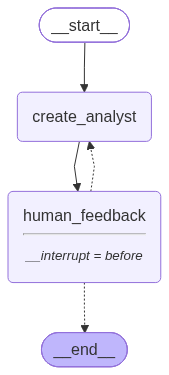

In [32]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [33]:
topic = "the benefits of adopting Langgraph as an agent framework"

In [34]:
max_analysts = 4

In [35]:
thread =  {"configurable":{"thread_id":1}}

In [36]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Name: Dr. Sarah Chen
Affiliation: Enterprise AI Solutions Lab
Role: AI Architecture Specialist
Description: Dr. Chen focuses on the technical architecture and design patterns enabled by Langgraph. She is particularly interested in how Langgraph's graph-based approach to agent orchestration compares to traditional sequential frameworks, examining state management, control flow flexibility, and the ability to build complex multi-agent systems. Her primary concern is understanding how Langgraph's architecture enables more maintainable and scalable agent applications, and she evaluates the framework's technical merits for production deployments.
--------------------------------------------------
Name: Marcus Rodriguez
Affiliation: DevTools Innovation Institute
Role: Developer Experience Researcher
Description: Marcus specializes in developer productivity and the practical aspects of adopting new frameworks. He examines Langgraph from the perspective of ease of use, learning curve, debuggin

In [37]:
state = graph.get_state(thread)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]


In [38]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Sarah Chen', role='AI Architecture Specialist', affiliation='Enterprise AI Solutions Lab', description="Dr. Chen focuses on the technical architecture and design patterns enabled by Langgraph. She is particularly interested in how Langgraph's graph-based approach to agent orchestration compares to traditional sequential frameworks, examining state management, control flow flexibility, and the ability to build complex multi-agent systems. Her primary concern is understanding how Langgraph's architecture enables more maintainable and scalable agent applications, and she evaluates the framework's technical merits for production deployments."), Analyst(name='Marcus Rodriguez', role='Developer Experience Researcher', affiliation='DevTools Innovation Institute', description='Marcus specializes in developer productivity and the practical aspects of adopt

In [39]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Sarah Chen', role='AI Architecture Specialist', affiliation='Enterprise AI Solutions Lab', description="Dr. Chen focuses on the technical architecture and design patterns enabled by Langgraph. She is particularly interested in how Langgraph's graph-based approach to agent orchestration compares to traditional sequential frameworks, examining state management, control flow flexibility, and the ability to build complex multi-agent systems. Her primary concern is understanding how Langgraph's architecture enables more maintainable and scalable agent applications, and she evaluates the framework's technical merits for production deployments."),
  Analyst(name='Marcus Rodriguez', role='Developer Experience Researcher', affiliation='DevTools Innovation Institute', description='Marcus specializes in developer productivity and the practical aspects of adopting new framework

In [40]:
state.next

('human_feedback',)

In [41]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f19bacb-9c6f-6acb-bfff-7576998d9838': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-08-19T09:02:37.870096+00:00\xa2id\xd9$1f19bacb-9c6f-6acb-bfff-7576998d9838\xb0channel_versions\x81\xa9__start__\xd9200000000000000000000000000000001.0.553641362269396\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f19bacb-9c78-658a-8000-830691af734a': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-08-19T09:02:37.873660+00:00\xa2id\xd9$1f19bacb-9c78-658a-8000-830691af734a\xb0channel_versions\x84\xa9__start__\xd9300000000000000000000000000000002.0.7201525023647573\xa5topic\xd9300000000000000000000000000000002.0.7201525023647573\xacmax_analysts\xd9300000000000000000000000000000002.0.7201525023647573\xb8branch:to:create_analyst\xd9300000000000000000000000000000002.0.7201525023647573\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start__\xd9

In [42]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19bacc-2b21-663d-8001-44abc553df70'}}

In [43]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19bacc-2ceb-63b3-8002-fc79675c0762'}}

In [44]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Sarah Chen
Affiliation: Enterprise AI Solutions Lab
Role: AI Architecture Specialist
Description: Dr. Chen focuses on the technical architecture and design patterns enabled by Langgraph. She is particularly interested in how Langgraph's graph-based approach to agent orchestration compares to traditional sequential frameworks, examining state management, control flow flexibility, and the ability to build complex multi-agent systems. Her primary concern is understanding how Langgraph's architecture enables more maintainable and scalable agent applications, and she evaluates the framework's technical merits for production deployments.
--------------------------------------------------
Name: Marcus Rodriguez
Affiliation: DevTools Innovation Institute
Role: Developer Experience Researcher
Description: Marcus specializes in developer productivity and the practical aspects of adopting new frameworks. He examines Langgraph from the perspective of ease of use, learning curve, debuggin

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Name: Dr. Sarah Chen
Affiliation: Fortune 500 Technology Consulting Firm
Role: Enterprise Architecture Strategist
Description: Dr. Chen specializes in evaluating emerging frameworks for large-scale enterprise applications. She focuses on how Langgraph can address complex orchestration challenges in modern enterprise AI systems, particularly around scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include production readiness, governance capabilities, and total cost of ownership for enterprise deployments. She is motivated by finding solutions that can handle mission-critical workloads while maintaining compliance and security standards.
--------------------------------------------------
Name: Marcus Rodriguez
Affiliation: AI-First SaaS Startup
Role: Startup CTO & Technical Co-founder
Description: Marcus leads technical strategy at a fast-growing startup building AI-powered products. He evaluates Langgraph from the perspective of rap

In [45]:
state = graph.get_state(thread)

In [46]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application', 'analysts': [Analyst(name='Dr. Sarah Chen', role='Enterprise Architecture Strategist', affiliation='Fortune 500 Technology Consulting Firm', description='Dr. Chen specializes in evaluating emerging frameworks for large-scale enterprise applications. She focuses on how Langgraph can address complex orchestration challenges in modern enterprise AI systems, particularly around scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include production readiness, governance capabilities, and total cost of ownership for enterprise deployments. She is motivated by finding solutions that can handle mission-critical workloads while maintaining compliance and security standards.'), Analyst(name='Marcus Rodriguez', role='Sta

In [47]:
state.next

('human_feedback',)

In [48]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application',
 'analysts': [Analyst(name='Dr. Sarah Chen', role='Enterprise Architecture Strategist', affiliation='Fortune 500 Technology Consulting Firm', description='Dr. Chen specializes in evaluating emerging frameworks for large-scale enterprise applications. She focuses on how Langgraph can address complex orchestration challenges in modern enterprise AI systems, particularly around scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include production readiness, governance capabilities, and total cost of ownership for enterprise deployments. She is motivated by finding solutions that can handle mission-critical workloads while maintaining compliance and security standards.'),
  Analyst(name='Marcus Rodriguez', role='Startup CTO & Techn

In [49]:
# If we are satisfied, then we simply supply no feedback
further_feedack = ""

In [50]:
# 1) Get the latest state (you're paused at 'human_feedback')
state = graph.get_state(thread)

# 2) Use the exact config from that state (it already has thread_id, checkpoint_ns, checkpoint_id)
cfg = state.config

In [51]:
# 3) Update feedback at the 'human_feedback' node
#    Tip: if your TypedDict says `human_analyst_feedback: str`, prefer "" (empty string) over None
graph.update_state(cfg, {"human_analyst_feedback": ""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19bacc-c083-6529-8006-c218f9b62a72'}}

In [52]:
# 4) Verify it moved to END
final_state = graph.get_state(thread)
print(final_state.next)  # should be (END,)

()


In [53]:
analysts = final_state.values.get('analysts')

In [54]:
analysts

[Analyst(name='Dr. Sarah Chen', role='Enterprise Architecture Strategist', affiliation='Fortune 500 Technology Consulting Firm', description='Dr. Chen specializes in evaluating emerging frameworks for large-scale enterprise applications. She focuses on how Langgraph can address complex orchestration challenges in modern enterprise AI systems, particularly around scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include production readiness, governance capabilities, and total cost of ownership for enterprise deployments. She is motivated by finding solutions that can handle mission-critical workloads while maintaining compliance and security standards.'),
 Analyst(name='Marcus Rodriguez', role='Startup CTO & Technical Co-founder', affiliation='AI-First SaaS Startup', description="Marcus leads technical strategy at a fast-growing startup building AI-powered products. He evaluates Langgraph from the perspective of rapid development vel

In [55]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Dr. Sarah Chen
Affiliation: Fortune 500 Technology Consulting Firm
Role: Enterprise Architecture Strategist
Description: Dr. Chen specializes in evaluating emerging frameworks for large-scale enterprise applications. She focuses on how Langgraph can address complex orchestration challenges in modern enterprise AI systems, particularly around scalability, reliability, and integration with existing enterprise infrastructure. Her primary concerns include production readiness, governance capabilities, and total cost of ownership for enterprise deployments. She is motivated by finding solutions that can handle mission-critical workloads while maintaining compliance and security standards.
--------------------------------------------------
Name: Marcus Rodriguez
Affiliation: AI-First SaaS Startup
Role: Startup CTO & Technical Co-founder
Description: Marcus leads technical strategy at a fast-growing startup building AI-powered products. He evaluates Langgraph from the perspective of rap

In [56]:
"The benefits of adopting LangGraph as an agent framework"

'The benefits of adopting LangGraph as an agent framework'

In [57]:
import wikipedia
wikipedia.set_lang("en")
wikipedia.set_user_agent("automated-research-synthesis/1.0 (contact: nicksri1248@proton.me)")

from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

C:\Users\shrin\AppData\Local\Temp\ipykernel_428\2804353377.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [58]:
from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="The benefits of adopting AWS Cloud").load()
print(docs)

[Document(metadata={'title': 'Cloud computing', 'summary': 'Cloud computing is defined by the International Organization for Standardization (ISO) as "a paradigm for enabling network access to a scalable and elastic pool of shareable physical or virtual resources with self-service provisioning and administration on demand". It is commonly referred to as "the cloud".', 'source': 'https://en.wikipedia.org/wiki/Cloud_computing'}, page_content='Cloud computing is defined by the International Organization for Standardization (ISO) as "a paradigm for enabling network access to a scalable and elastic pool of shareable physical or virtual resources with self-service provisioning and administration on demand". It is commonly referred to as "the cloud".\n\n\n== Characteristics ==\nIn 2011, the National Institute of Standards and Technology (NIST) identified five "essential characteristics" for cloud systems. Below are the exact definitions according to NIST:\n\nOn-demand self-service: "A consume

# Second Workflow

In [59]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [60]:
from dotenv import load_dotenv
load_dotenv()
import os
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [61]:
tavily_api_key

'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'

In [62]:
tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)

C:\Users\shrin\AppData\Local\Temp\ipykernel_428\1029971610.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)


In [63]:
tavily_search.invoke("langgraph")

[{'title': 'What is LangGraph? | Decagon glossary | Decagon',
  'url': 'https://decagon.ai/glossary/what-is-langgraph',
  'content': 'Introducing Duet Autopilot.\n\nLearn more\n\nSign in\n\nGet a demo\n\nGlossary\n\n# LangGraph\n\nLangGraph is an open-source orchestration framework for building stateful, multi-step AI agent workflows as directed graphs, where nodes represent actions or model calls and edges define the control flow between them. [...] ## How LangGraph works\n\nLangGraph represents an agent workflow as a stateful directed graph. Nodes are Python functions, model calls, or tool invocations. Edges are either unconditional, always proceeding to the next node, or conditional, routing to different nodes based on the output of the preceding step. A shared state object is passed through the graph, updated at each node, and available to all downstream nodes, which enables the kind of memory and context accumulation that multi-step customer service workflows require.\n\nKey archi

In [64]:
from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [65]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [66]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [67]:
print(analyst.persona)

Name: James Park
Role: Developer Experience & Ecosystem Analyst
Affiliation: Open Source Developer Community
Description: James evaluates frameworks from the perspective of developer adoption and ecosystem health. He focuses on Langgraph's learning curve, documentation quality, integration with popular tools and libraries, and the vibrancy of its community. His concerns include the framework's flexibility for different use cases, the availability of examples and templates, debugging tools, and how well it compares to alternative agent frameworks. He is motivated by understanding whether Langgraph provides a sustainable foundation for building the next generation of agent applications and how it empowers developers to be productive.



In [68]:
question_instructions.format(goals = analyst.persona)

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: James Park\nRole: Developer Experience & Ecosystem Analyst\nAffiliation: Open Source Developer Community\nDescription: James evaluates frameworks from the perspective of developer adoption and ecosystem health. He focuses on Langgraph\'s learning curve, documentation quality, integration with popular tools and libraries, and the vibrancy of its community. His concerns include the framework\'s flexibility for different use cases, the availability of examples and templates, debugging tools, and how well it compares to alternative agent frameworks. He is motivated by understanding whether Lang

In [69]:
'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Michael Chen\nRole: Business Strategy Consultant\nAffiliation: FutureTech Consulting\nDescription: Michael analyzes the strategic implications of adopting Langgraph for businesses. He focuses on how the framework can drive innovation, support digital transformation initiatives, and align with long-term business goals.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRemember to stay in character throughout your response, reflecting the persona and goals provided to you.'

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Michael Chen\nRole: Business Strategy Consultant\nAffiliation: FutureTech Consulting\nDescription: Michael analyzes the strategic implications of adopting Langgraph for businesses. He focuses on how the framework can drive innovation, support digital transformation initiatives, and align with long-term business goals.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you

In [70]:
def generation_question(state:InterviewState):
    """Node to generate the questions"""
    
    #get state
    analyst = state["analyst"]
    messages = state["messages"]
    
    #generate the question
    system_message = question_instructions.format(goals = analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    #returen the question through state
    return {"messages":[question]}

In [71]:
analyst

Analyst(name='James Park', role='Developer Experience & Ecosystem Analyst', affiliation='Open Source Developer Community', description="James evaluates frameworks from the perspective of developer adoption and ecosystem health. He focuses on Langgraph's learning curve, documentation quality, integration with popular tools and libraries, and the vibrancy of its community. His concerns include the framework's flexibility for different use cases, the availability of examples and templates, debugging tools, and how well it compares to alternative agent frameworks. He is motivated by understanding whether Langgraph provides a sustainable foundation for building the next generation of agent applications and how it empowers developers to be productive.")

In [72]:
class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

In [73]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],"messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [74]:
state

{'max_num_turns': 2,
 'context': [],
 'analyst': Analyst(name='James Park', role='Developer Experience & Ecosystem Analyst', affiliation='Open Source Developer Community', description="James evaluates frameworks from the perspective of developer adoption and ecosystem health. He focuses on Langgraph's learning curve, documentation quality, integration with popular tools and libraries, and the vibrancy of its community. His concerns include the framework's flexibility for different use cases, the availability of examples and templates, debugging tools, and how well it compares to alternative agent frameworks. He is motivated by understanding whether Langgraph provides a sustainable foundation for building the next generation of agent applications and how it empowers developers to be productive."),
 'interview': '',
 'section': [],
 'messages': [HumanMessage(content='hi do the proper search according to the experties', additional_kwargs={}, response_metadata={})]}

In [75]:
result = generation_question(state)

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


In [76]:
result

{'messages': [AIMessage(content='Hello! My name is James Park, and I\'m a Developer Experience & Ecosystem Analyst working with the Open Source Developer Community. I spend my time evaluating frameworks through the lens of developer adoption, ecosystem health, and long-term sustainability.\n\nI\'m currently conducting a deep analysis of Langgraph, and I\'d love to get your expert perspective on this framework.\n\nTo start, I\'d like to understand the fundamentals from a developer experience standpoint:\n\n**What has been your experience with Langgraph\'s learning curve compared to other agent frameworks you\'ve worked with?** Specifically, I\'m curious about:\n\n- How long it typically takes developers to go from "hello world" to building a production-ready agent\n- What are the most common pain points or "aha moments" developers encounter\n- Are there particular concepts or abstractions in Langgraph that developers find either particularly intuitive or confusing?\n\nI\'m trying to gau

In [77]:
print(result["messages"][0].content)

Hello! My name is James Park, and I'm a Developer Experience & Ecosystem Analyst working with the Open Source Developer Community. I spend my time evaluating frameworks through the lens of developer adoption, ecosystem health, and long-term sustainability.

I'm currently conducting a deep analysis of Langgraph, and I'd love to get your expert perspective on this framework.

To start, I'd like to understand the fundamentals from a developer experience standpoint:

**What has been your experience with Langgraph's learning curve compared to other agent frameworks you've worked with?** Specifically, I'm curious about:

- How long it typically takes developers to go from "hello world" to building a production-ready agent
- What are the most common pain points or "aha moments" developers encounter
- Are there particular concepts or abstractions in Langgraph that developers find either particularly intuitive or confusing?

I'm trying to gauge whether Langgraph provides an accessible entry poi

In [78]:
from langchain_core.messages import get_buffer_string

In [79]:
# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [80]:
def search_web(state:InterviewState):
    """
    Retrieve data from the web
    """
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions]+state["messages"])
    
    # Search
    search_docs = tavily_search.invoke(search_query.search_query)
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [81]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [82]:
result = search_web(state)

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


In [83]:
print(result["context"][0])

<Document href="https://technocetus.com/blog/how-langgraph-powers-complex-ai-workflows-the-business-transformation-framework-for-2026"/>
LangGraph is changing that. Built by the team at LangChain, LangGraph is an open-source framework for building stateful, multi-agent AI workflows — the infrastructure layer that turns powerful but isolated AI models into coordinated, production-grade systems. For engineering teams and business leaders trying to move from AI experimentation to business transformation, understanding LangGraph isn't optional. It's foundational.

## The Problem LangGraph Solves: Why Linear AI Chains Break Down

To understand why LangGraph matters, you first need to understand what it replaces. [...] ## The Bottom Line

LangGraph represents the maturation of enterprise AI automation — the moment the industry moved from building impressive demos to building reliable systems. The framework's ability to orchestrate stateful, cyclical, multi-agent workflows with native human o

In [84]:
def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

In [85]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [86]:
result = search_wikipedia(state)

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


*******************************
search_query='Langgraph framework business innovation digital transformation'


In [87]:
search_docs = WikipediaLoader(query='Langgraph framework benefits',load_all_available_meta=True).load()

In [88]:
search_docs

[]

In [89]:
result

{'context': ['']}

In [90]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [91]:
def generate_answer(state:InterviewState):
   
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}
    

In [92]:
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return "ask_question"

In [93]:
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

In [94]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [95]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

In [96]:
interview_builder = StateGraph(InterviewState)

In [97]:
interview_builder.add_node("ask_question",generation_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

In [98]:
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                           route_messages,
                           ["ask_question",
                            "save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)

In [99]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")

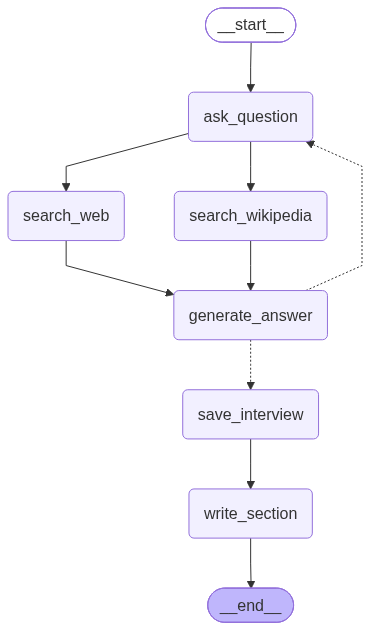

In [100]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [101]:
analyst

Analyst(name='James Park', role='Developer Experience & Ecosystem Analyst', affiliation='Open Source Developer Community', description="James evaluates frameworks from the perspective of developer adoption and ecosystem health. He focuses on Langgraph's learning curve, documentation quality, integration with popular tools and libraries, and the vibrancy of its community. His concerns include the framework's flexibility for different use cases, the availability of examples and templates, debugging tools, and how well it compares to alternative agent frameworks. He is motivated by understanding whether Langgraph provides a sustainable foundation for building the next generation of agent applications and how it empowers developers to be productive.")

In [102]:
analyst.persona

"Name: James Park\nRole: Developer Experience & Ecosystem Analyst\nAffiliation: Open Source Developer Community\nDescription: James evaluates frameworks from the perspective of developer adoption and ecosystem health. He focuses on Langgraph's learning curve, documentation quality, integration with popular tools and libraries, and the vibrancy of its community. His concerns include the framework's flexibility for different use cases, the availability of examples and templates, debugging tools, and how well it compares to alternative agent frameworks. He is motivated by understanding whether Langgraph provides a sustainable foundation for building the next generation of agent applications and how it empowers developers to be productive.\n"

In [103]:
thread = {"configurable": {"thread_id": "1"}}

In [104]:
from IPython.display import Markdown

In [105]:
messages = [HumanMessage("So you said you were writing an article on Langchain?")]

In [106]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


*******************************
search_query='Langgraph vs Langchain differences pain points limitations developer problems'


HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


*******************************
search_query='Langgraph vs Langchain differences pain points limitations developer problems'


HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


In [107]:
Markdown(interview['sections'][0])

## LangGraph's Developer Journey: Navigating the Complexity-Power Trade-off

### Summary

The developer experience with LangGraph reveals a fundamental architectural decision that shapes the entire agent framework landscape. Rather than competing with LangChain, LangGraph represents a complementary layer in the same stack—a distinction that became official with the October 22, 2025 v1.0 milestone when LangChain Inc. formally defined the division of labor between its two frameworks [1]. This architectural clarity is particularly significant for developers evaluating long-term sustainability, as it positions LangGraph not as a replacement but as the orchestration runtime that powers complex agent workflows.

What emerges as most striking is the consistent developer consensus around LangGraph's learning curve versus its production payoff. The framework demands upfront investment in understanding nodes, edges, state machines, checkpointers, and threads—concepts that carry "more conceptual overhead" than traditional pipeline approaches [2]. Developers need object-oriented programming knowledge to define state schemas and node functions, creating a steeper initial climb [3]. However, the community consistently reports that "once the model clicks, multi-agent and human-in-the-loop patterns become routine instead of bespoke" [2].

The framework's real-world adoption signals strong ecosystem health. GitHub activity shows rapid growth with expanding examples and production case studies from major technology companies including Uber, LinkedIn, Klarna, Replit, and Elastic [2]. Community discussions on Reddit and forums consistently recommend a specific learning path: master LangChain basics first, then layer LangGraph for orchestration [2]. This pattern suggests a maturing ecosystem with established best practices rather than fragmented approaches.

The documentation landscape presents a mixed picture. While LangChain 1.0 cleaned up many v0.x pain points around tool calling and removed older AgentExecutor sharp edges, users still flag maintenance churn from frequent updates [2]. LangGraph's documentation is described as "spotty" [3], yet the framework's flexibility makes it favored by advanced developers who can navigate these gaps.

Perhaps most revealing is the practical trade-off developers face: LangChain code is faster to write, but LangGraph code "survives a server crash mid-flow and can pause for human approval between nodes" [2]. This durability versus velocity tension defines the framework choice. For developers building next-generation agent applications, LangGraph's explicit state management, native loop support, and built-in exception handling [4] provide production-grade capabilities that justify the steeper learning investment—particularly for applications expected to grow in complexity over time [1].

### Sources

[1] https://www.truefoundry.com/blog/langchain-vs-langgraph  
[2] https://peliqan.io/blog/langchain-vs-langgraph  
[3] https://duplocloud.com/blog/langchain-vs-langgraph  
[4] https://milvus.io/blog/langchain-vs-langgraph.md  
[5] https://atlan.com/know/ai-agent/ai-agent-memory/langchain-vs-langgraph

# Third Workflow

In [108]:
from typing_extensions import TypedDict
from typing import List, Annotated
import operator
class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report
    
# class InterviewState(MessagesState):
#     max_num_turns: int # Number turns of conversation
#     context: Annotated[list, operator.add] # Source docs
#     analyst: Analyst # Analyst asking questions
#     interview: str # Interview transcript
#     sections: list # Final key we duplicate in outer state for Send() API

In [109]:
from langgraph.types import Send

In [110]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """ 
    
    #check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"
    
    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                        "messages": [HumanMessage(
                                            content=f"So you said you were writing an article on {topic}?"
                                        )
                                                ]}) for analyst in state["analysts"]]

In [111]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

In [112]:
def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

In [113]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [114]:
def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

In [115]:
def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

In [116]:
def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [117]:
# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

In [118]:
memory = MemorySaver()

In [119]:
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

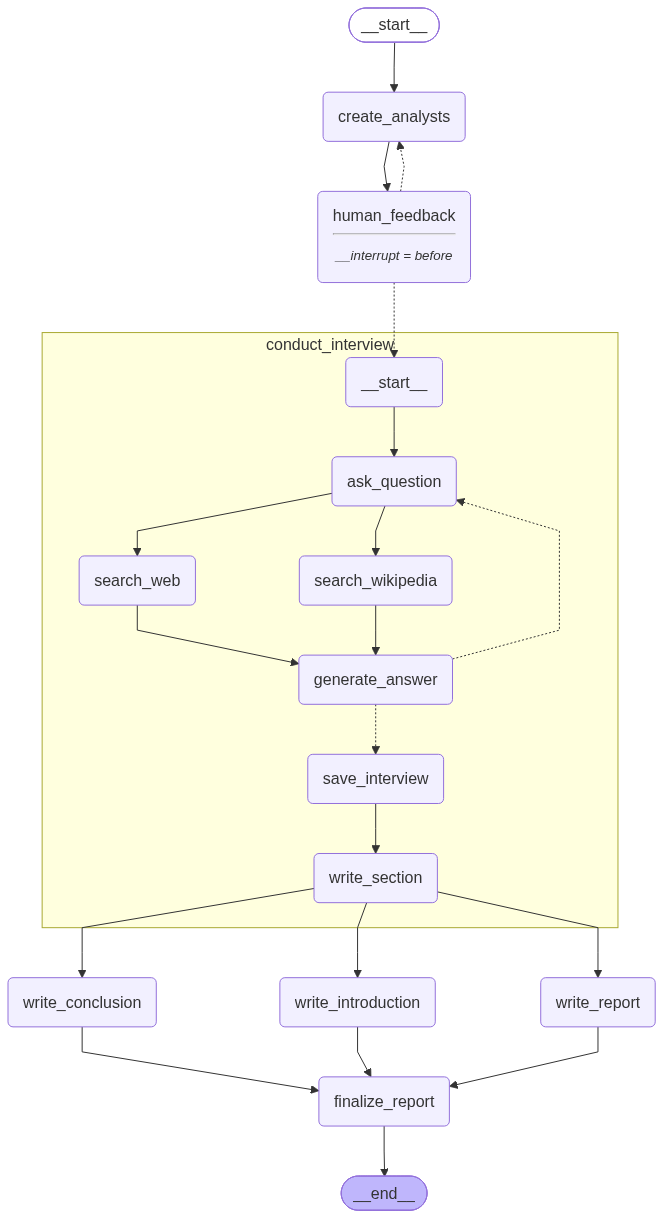

In [120]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [121]:
max_analysts = 3

In [122]:
topic = "How can generative help us to play the cricket?"

In [123]:
topic = "How can generative AI accelerate drug discovery?"

In [124]:
thread = {"configurable": {"thread_id": "1"}}

In [125]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Name: Dr. Sarah Chen
Affiliation: Computational Biology Research Institute
Role: AI-Driven Drug Design Specialist
Description: Dr. Chen focuses on how generative AI models, particularly deep learning architectures like transformers and diffusion models, can design novel molecular structures with desired therapeutic properties. She is concerned with the technical capabilities of AI to generate drug candidates that are both chemically valid and biologically active, while being motivated to reduce the time and cost traditionally required in the early stages of drug discovery. Her expertise spans molecular generation, property prediction, and the integration of multi-modal data to optimize lead compounds.
--------------------------------------------------
Name: Dr. Marcus Rodriguez
Affiliation: Pharmaceutical Development Consortium
Role: Clinical Translation and Validation Expert
Description: Dr. Rodriguez examines the pathway from AI-generated drug candidates to clinical applications, foc

In [126]:
graph.update_state(thread, {"human_analyst_feedback":"along with the genetive ai in future tell me the future of indian team"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19bad5-0f1a-634c-8002-6bf98b8e6f86'}}

In [127]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Sarah Chen
Affiliation: Computational Biology Research Institute
Role: AI-Driven Drug Design Specialist
Description: Dr. Chen focuses on how generative AI models, particularly deep learning architectures like transformers and diffusion models, can design novel molecular structures with desired therapeutic properties. She is concerned with the technical capabilities of AI to generate drug candidates that are both chemically valid and biologically active, while being motivated to reduce the time and cost traditionally required in the early stages of drug discovery. Her expertise spans molecular generation, property prediction, and the integration of multi-modal data to optimize lead compounds.
--------------------------------------------------
Name: Dr. Marcus Rodriguez
Affiliation: Pharmaceutical Development Consortium
Role: Clinical Translation and Validation Expert
Description: Dr. Rodriguez examines the pathway from AI-generated drug candidates to clinical applications, foc

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Name: Dr. Priya Sharma
Affiliation: Computational Biology Research Institute
Role: AI-Driven Drug Discovery Specialist
Description: Dr. Sharma focuses on how generative AI models, particularly deep learning and transformer architectures, can revolutionize the drug discovery pipeline by predicting molecular structures, optimizing drug candidates, and reducing time-to-market for new therapeutics. She is motivated by the potential to accelerate treatments for rare diseases and improve success rates in clinical trials through AI-powered molecular design and virtual screening.
--------------------------------------------------
Name: Dr. Rajesh Kumar
Affiliation: Indian Pharmaceutical Alliance
Role: Pharmaceutical Innovation Strategist
Description: Dr. Kumar examines the future of India's pharmaceutical industry and its position in the global drug discovery landscape. He is particularly interested in how Indian biotech companies and research institutions can leverage generative AI to compete

In [128]:
graph.update_state(thread, {"human_analyst_feedback":""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19bad5-6a74-6d61-8006-ab4bf538b4d7'}}

In [129]:
graph.get_state(thread).next

('conduct_interview', 'conduct_interview', 'conduct_interview')

In [130]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


*******************************
search_query='generative AI drug discovery bottlenecks traditional pipeline acceleration'


HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


*******************************
search_query='generative AI accelerate drug discovery India pharmaceutical companies concrete applications results'


HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


...

--Node--
write_conclusion


HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


--Node--
write_introduction


HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


--Node--
write_report
--Node--
finalize_report


In [131]:
from IPython.display import Markdown

In [132]:
final_state = graph.get_state(thread)

In [133]:
report = final_state.values.get('final_report')

In [134]:
Markdown(report)

# Generative AI: Revolutionizing Drug Discovery from Promise to Practice

## Introduction

The pharmaceutical industry faces a critical paradox: while developing life-saving therapeutics has never been more scientifically possible, the traditional drug discovery pipeline remains extraordinarily inefficient, requiring 10-15 years and billions of dollars to bring a single candidate to market. Generative AI is emerging as a transformative solution, demonstrating the potential to compress discovery timelines by up to 70%—from over a decade to as little as 1-2 years. This report examines three critical dimensions of this revolution: first, how generative AI achieves unprecedented acceleration through deep learning architectures that design novel molecules and predict their properties in silico; second, India's strategic opportunity to transition from volume-based manufacturing to value-driven innovation leadership in AI-powered drug development; and third, the sobering translation challenges that threaten to create a preclinical validation bottleneck, where computational breakthroughs struggle to convert into clinical success due to inadequate human-relevant testing platforms and data quality limitations.

---



The pharmaceutical industry stands at a transformative inflection point where generative AI promises to fundamentally reshape drug discovery timelines and economics, yet faces critical challenges in translating computational breakthroughs into clinical success. The traditional drug development pipeline—requiring 10-15 years and resulting in only 1 in 8 candidates surviving to approval—is being compressed by up to 70% through advanced deep learning architectures including variational autoencoders, generative adversarial networks, and transformers [1][2]. This represents a quantum leap beyond conventional AI approaches, which typically achieve approximately 50% timeline reductions.

Real-world implementations validate these dramatic improvements. Exscientia has cut early design efforts by 70% while slashing capital costs by 80% [1][2]. Insilico Medicine delivered a preclinical candidate for Idiopathic Pulmonary Fibrosis in just 13-18 months at approximately $2.6 million—compared to traditional timelines of 2.5-4 years at substantially higher cost [1][2]. Their Chemistry42 engine optimized around 40 molecules within four months for a MASH therapeutics program, and the company now maintains a pipeline of 30 AI-powered assets with 10 having received IND clearance [1]. Drug target identification can now be accelerated by 70%, compressing timelines from over 12 months to just 3 months [3].

The technology enables the creation of "designer drugs" with pre-optimized properties for efficacy, safety, and pharmacokinetics before synthesis [1]. By generating entirely new chemical entities from scratch rather than merely screening existing compounds, generative AI significantly reduces the need for extensive post-discovery optimization and increases the probability of clinical success. The technology also facilitates drug repurposing by retrospectively analyzing existing clinical data to identify novel therapeutic indications for previously approved drugs, bypassing initial safety trials [4]. Generative AI now dominates 22.4% of the pharmaceutical market share, with the AI in drug discovery market projected to grow at a remarkable 37.67% CAGR from 2024 to 2030 [5][6].

This technological shift presents a significant strategic opportunity for India to establish itself as a leader in AI-enabled pharmaceutical innovation, moving beyond its traditional role as a volume-based manufacturer to become a value-driven innovator in global drug development. Prominent Indian contract research organizations, contract development and manufacturing organizations, and leading pharmaceutical firms are actively harnessing generative AI to reshape the entire R&D value chain [7]. The EY Parthenon report "From Volume to Value: Indian Pharma's Transformation with Data and AI," launched at BioAsia 2024 in collaboration with the Government of Telangana, underscores how Indian companies are leveraging AI algorithms to revolutionize R&D operations, streamline clinical trials, and enhance operational efficiencies [7]. This marks a strategic shift toward positioning India at the forefront of drug development, particularly for complex diseases including cancer, Alzheimer's, arthritis, fibrosis, and rare diseases [7].

However, beneath these impressive computational achievements lies a critical and underappreciated challenge: the vast majority of AI's demonstrated impact occurs in early-stage, in-silico discovery phases, with limited evidence of translation to clinical success [8]. A systematic review of 100 peer-reviewed studies reveals that while AI significantly reduces timelines for molecule identification and lead optimization, much of this evidence remains confined to proof-of-concept studies. In preclinical development, applications remain limited with sparse prospective validation, and clinical adoption shows efficiency gains primarily in cost reduction rather than time savings, with no robust evidence that computational acceleration translates into reduced attrition or regulatory progress [8].

Most striking is the emerging recognition of the "preclinical bottleneck" [9]. The generative AI revolution in molecular design threatens to transform drug discovery's chronic inefficiency into an acute crisis by dramatically expanding throughput at the design stage while the validation pipeline continues to rely on animal models that operate on fundamentally different physiology from human trials, resulting in a 95-99% failure rate when candidates transition to human testing [9]. This fundamental mismatch—where drug discovery has a development environment but lacks a proper test environment aligned with human physiology—represents a critical barrier to realizing AI's promise.

Additional challenges compound this translation gap. Data quality emerges as a significant concern, as AI models require robust, unbiased datasets; incomplete or skewed data can lead to ineffective drug candidates [6]. Public datasets prove inadequate for AI training, being too heterogeneous, sparse in perturbations, and biased in sample composition to robustly train models that generalize across discovery pipelines [10]. Traditional RNA-seq methods cannot generate the hundreds of thousands to millions of standardized perturbation expression profiles that robust AI training demands at feasible cost or timescale [10]. Regulatory uncertainty looms as agencies like the FDA adapt frameworks to AI-driven development, while integrating AI into traditional workflows requires substantial cultural and technical shifts within pharmaceutical organizations [6].

The path forward requires addressing these translational challenges while capitalizing on generative AI's demonstrated strengths in molecular design and optimization. Success will depend on developing human-relevant validation platforms that can match the throughput of AI-powered discovery, establishing robust data infrastructure for model training, and navigating evolving regulatory frameworks. For countries like India seeking to establish leadership in this space, the opportunity lies not merely in adopting AI tools but in building comprehensive ecosystems that bridge the gap between computational innovation and clinical validation.


---

## Conclusion

Generative AI represents a transformative force in pharmaceutical development, demonstrating unprecedented potential to compress drug discovery timelines by up to 70% and reduce early-stage costs by 80%. Real-world successes from Insilico Medicine, Exscientia, and others validate the technology's capacity to revolutionize molecular design and optimization. For nations like India, this presents a strategic opportunity to transition from volume-based manufacturing to value-driven innovation leadership. However, the translation from computational promise to clinical reality remains incomplete. The emerging preclinical validation bottleneck—where animal models fail to predict human outcomes 95-99% of the time—threatens to transform chronic inefficiency into acute crisis as AI accelerates upstream throughput. Realizing generative AI's full potential requires not just better algorithms, but fundamentally improved human-relevant validation platforms, robust training datasets, regulatory frameworks, and organizational integration. The revolution in drug discovery will be won not in silicon alone, but in successfully bridging the gap between computational design and clinical translation.

## Sources

[1] https://www.drugpatentwatch.com/blog/ai-driven-drug-discovery-transforming-the-landscape-of-pharmaceutical-research
[2] https://prajnaaiwisdom.medium.com/how-generative-ai-is-reducing-drug-discovery-timelines-by-70-e86d58f7c780
[3] https://www.linkedin.com/posts/bogdanknezevic_breaking-the-me-too-drug-cycle-in-biotech-activity-7363614169482313731-U-q4
[4] https://digitalcommons.liu.edu/symposium_discoveryday/2026/posters/52
[5] https://market.us/report/generative-ai-in-pharmaceutical-market
[6] https://www.delveinsight.com/blog/generative-ai-drug-discovery-market-impact
[7] https://www.ey.com/en_in/insights/health/how-gen-ai-is-revolutionizing-the-pharmaceutical-industry
[8] https://www.sciencedirect.com/science/article/pii/S2949866X25000784
[9] https://www.drugdiscoveryonline.com/doc/ai-drug-discovery-is-revealing-the-preclinical-bottleneck-0001
[10] https://alitheagenomics.com/how-high-throughput-transcriptomics-solves-the-ai-training-data-bottleneck-in-drug-discovery